In [1]:
import csv

import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split

RANDOM_SEED = 42

# 경로 설정

In [2]:
dataset = 'model/point_history_classifier/point_history.csv'
model_save_path = 'model/point_history_classifier/point_history_classifier.h5'

# 분류 수 설정

In [3]:
NUM_CLASSES = 4

# 입력 길이

In [4]:
TIME_STEPS = 16
DIMENSION = 2

# 학습 데이터 로드

In [5]:
X_dataset = np.loadtxt(dataset, delimiter=',', dtype='float32', usecols=list(range(1, (TIME_STEPS * DIMENSION) + 1)))

In [6]:
y_dataset = np.loadtxt(dataset, delimiter=',', dtype='int32', usecols=(0))

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X_dataset, y_dataset, train_size=0.75, random_state=RANDOM_SEED)

# 모델 구성

In [8]:
use_lstm = False
model = None

if use_lstm:
    model = tf.keras.models.Sequential([
        tf.keras.layers.InputLayer(input_shape=(TIME_STEPS * DIMENSION, )),
        tf.keras.layers.Reshape((TIME_STEPS, DIMENSION), input_shape=(TIME_STEPS * DIMENSION, )), 
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.LSTM(16, input_shape=[TIME_STEPS, DIMENSION]),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(10, activation='relu'),
        tf.keras.layers.Dense(NUM_CLASSES, activation='softmax')
    ])
else:
    model = tf.keras.models.Sequential([
        tf.keras.layers.InputLayer(input_shape=(TIME_STEPS * DIMENSION, )),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Dense(24, activation='relu'),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(10, activation='relu'),
        tf.keras.layers.Dense(NUM_CLASSES, activation='softmax')
    ])

/opt/homebrew/Caskroom/miniconda/base/envs/tf-mac-metal/lib/python3.11/site-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


In [9]:
model.summary()  # tf.keras.utils.plot_model(model, show_shapes=True)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 24)             │           792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 24)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           250 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │            44 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,086 (4.24 KB)

 Trainable params: 1,086 (4.24 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
# 모델 체크포인트 콜백
cp_callback = tf.keras.callbacks.ModelCheckpoint(
    model_save_path, verbose=1, save_weights_only=False)
# 조기 종료 콜백
es_callback = tf.keras.callbacks.EarlyStopping(patience=20, verbose=1)

In [11]:
# 모델 컴파일
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 모델 학습

In [12]:
model.fit(
    X_train,
    y_train,
    epochs=1000,
    batch_size=128,
    validation_data=(X_test, y_test),
    callbacks=[cp_callback, es_callback]
)

Epoch 1/1000
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.2646 - loss: 1.3970
Epoch 1: saving model to model/point_history_classifier/point_history_classifier.h5



Epoch 1: finished saving model to model/point_history_classifier/point_history_classifier.h5
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - accuracy: 0.2465 - loss: 1.4023 - val_accuracy: 0.1956 - val_loss: 1.3898
Epoch 2/1000
31/32 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.2451 - loss: 1.3963
Epoch 2: saving model to model/point_history_classifier/point_history_classifier.h5



Epoch 2: finished saving model to model/point_history_classifier/point_history_classifier.h5
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.2545 - loss: 1.3984 - val_accuracy: 0.2500 - val_loss: 1.3893
Epoch 3/1000
31/32 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.3241 - loss: 1.4016
Epoch 3: saving model to model/point_history_classifier/point_history_classifier.h5



Epoch 3: finished saving model to model/point_history_classifier/point_history_classifier.h5
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.3371 - loss: 1.3997 - val_accuracy: 0.5446 - val_loss: 1.3890
Epoch 4/1000
31/32 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.3314 - loss: 1.4011
Epoch 4: saving model to model/point_history_classifier/point_history_classifier.h5



Epoch 4: finished saving model to model/point_history_classifier/point_history_classifier.h5
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.3459 - loss: 1.4023 - val_accuracy: 0.5325 - val_loss: 1.3887
Epoch 5/1000
31/32 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.3352 - loss: 1.4004
Epoch 5: saving model to model/point_history_classifier/point_history_classifier.h5


...


Epoch 56: finished saving model to model/point_history_classifier/point_history_classifier.h5
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.2601 - loss: 1.4778 - val_accuracy: 0.3693 - val_loss: 1.3892
Epoch 57/1000
31/32 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.2779 - loss: 1.4571
Epoch 57: saving model to model/point_history_classifier/point_history_classifier.h5



Epoch 57: finished saving model to model/point_history_classifier/point_history_classifier.h5
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.2742 - loss: 1.4745 - val_accuracy: 0.3406 - val_loss: 1.3903
Epoch 58/1000
31/32 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.2577 - loss: 1.4650
Epoch 58: saving model to model/point_history_classifier/point_history_classifier.h5



Epoch 58: finished saving model to model/point_history_classifier/point_history_classifier.h5
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.2581 - loss: 1.4651 - val_accuracy: 0.4396 - val_loss: 1.4137
Epoch 59/1000
31/32 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.2649 - loss: 1.4937
Epoch 59: saving model to model/point_history_classifier/point_history_classifier.h5



Epoch 59: finished saving model to model/point_history_classifier/point_history_classifier.h5
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.2649 - loss: 1.4756 - val_accuracy: 0.3927 - val_loss: 1.3921
Epoch 60/1000
31/32 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.2678 - loss: 1.5076
Epoch 60: saving model to model/point_history_classifier/point_history_classifier.h5



Epoch 60: finished saving model to model/point_history_classifier/point_history_classifier.h5
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.2681 - loss: 1.5106 - val_accuracy: 0.3369 - val_loss: 1.3910
Epoch 60: early stopping


In [13]:
# 저장된 모델 로드
model = tf.keras.models.load_model(model_save_path)

In [14]:
# 추론 테스트
predict_result = model.predict(np.array([X_test[0]]))
print(np.squeeze(predict_result))
print(np.argmax(np.squeeze(predict_result)))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
[0.2788548  0.23257983 0.2567651  0.23180033]
0


# 혼동 행렬

42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


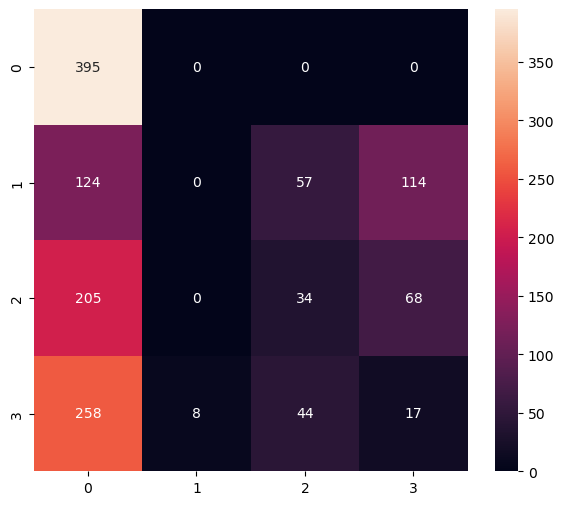

Classification Report
              precision    recall  f1-score   support

           0       0.40      1.00      0.57       395
           1       0.00      0.00      0.00       295
           2       0.25      0.11      0.15       307
           3       0.09      0.05      0.06       327

    accuracy                           0.34      1324
   macro avg       0.18      0.29      0.20      1324
weighted avg       0.20      0.34      0.22      1324



In [15]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

def print_confusion_matrix(y_true, y_pred, report=True):
    labels = sorted(list(set(y_true)))
    cmx_data = confusion_matrix(y_true, y_pred, labels=labels)
    
    df_cmx = pd.DataFrame(cmx_data, index=labels, columns=labels)
 
    fig, ax = plt.subplots(figsize=(7, 6))
    sns.heatmap(df_cmx, annot=True, fmt='g' ,square=False)
    ax.set_ylim(len(set(y_true)), 0)
    plt.show()
    
    if report:
        print('Classification Report')
        print(classification_report(y_test, y_pred))

Y_pred = model.predict(X_test)
y_pred = np.argmax(Y_pred, axis=1)

print_confusion_matrix(y_test, y_pred)

# TensorFlow Lite 모델로 변환

In [16]:
# 추론 전용 모델로 저장
model.save(model_save_path, include_optimizer=False)
model = tf.keras.models.load_model(model_save_path)

In [ ]:
tflite_save_path = 'model/point_history_classifier/point_history_classifier.tflite'

: 

In [ ]:
# 모델 변환 (양자화)
converter = tf.lite.TFLiteConverter.from_keras_model(model)  # converter = tf.lite.TFLiteConverter.from_saved_model(saved_model_path)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_quantized_model = converter.convert()

open(tflite_save_path, 'wb').write(tflite_quantized_model)

INFO:tensorflow:Assets written to: /var/folders/2r/d3kbwmbx08n2cmp093003gbw0000gn/T/tmp5rhhip0j/assets


INFO:tensorflow:Assets written to: /var/folders/2r/d3kbwmbx08n2cmp093003gbw0000gn/T/tmp5rhhip0j/assets


# 추론 테스트 (TFLite)

In [ ]:
interpreter = tf.lite.Interpreter(model_path=tflite_save_path)
interpreter.allocate_tensors()

: 

: 

: 

: 

: 

In [ ]:
# 입출력 텐서 취득
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()
print(input_details)

[{'name': 'input_1', 'index': 0, 'shape': array([ 1, 32]), 'shape_signature': array([-1, 32]), 'dtype': <class 'numpy.float32'>, 'quantization': (0.0, 0), 'quantization_parameters': {'scales': array([], dtype=float32), 'zero_points': array([], dtype=int32), 'quantized_dimension': 0}, 'sparsity_parameters': {}}]


: 

: 

: 

: 

: 

In [ ]:
interpreter.set_tensor(input_details[0]['index'], np.array([X_test[0]]))

: 

: 

: 

: 

: 

In [ ]:
%%time
# 추론 실행
interpreter.invoke()
tflite_results = interpreter.get_tensor(output_details[0]['index'])

Wall time: 0 ns


: 

: 

: 

: 

: 

In [ ]:
print(np.squeeze(tflite_results))
print(np.argmax(np.squeeze(tflite_results)))

[0.9579909  0.01342559 0.00907356 0.01950999]
0


: 

: 

: 

: 

: 